# Fair Model Comparison: Qwen3.5:9b vs Qwen2.5-VL

## Objective
Accurately compare the artistic understanding and clustering capabilities of **Qwen3.5:9b** (General LLM with Vision) and **Qwen2.5-VL** (Native Vision-Language Model) using the exact same prompt and pipeline.

## The Fair Test Plan
1.  **The Prompt:** Use a single, comprehensive "dense paragraph" prompt asking for Subject, Composition, Lighting, Tonal Range, Mood, and Style.
2.  **Data Generation (Live):** Take a sample of 20 images from `data/raw/`.
    *   Run them through `qwen3.5:9b` via the local Ollama API.
    *   Run them through `Qwen2.5-VL` via the local `mlx_vlm` library.
3.  **Embedding:** Convert the resulting text descriptions from both models into numerical vectors using `nomic-embed-text` via Ollama.
4.  **Clustering:** Apply the exact same UMAP + HDBSCAN pipeline to both sets of embeddings to discover natural style groups.
5.  **Visualization:**
    *   Display side-by-side text descriptions generated by both models to compare their artistic vocabulary.
    *   Display the resulting image clusters side-by-side to evaluate which model produced more cohesive, visually consistent groups.

In [1]:
import torch
from transformers import CLIPProcessor, CLIPModel
import duckdb
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import json
import time
import base64
import urllib.request
import requests
from sklearn.cluster import HDBSCAN
import umap
from mlx_vlm import load as mlx_load
from mlx_vlm.utils import load_config
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm import generate as mlx_generate

# --- Config ---
RAW_DIR = Path("./data/raw")
OLLAMA_MODEL = "qwen3.5:9b"
VLM_MODEL_ID = "mlx-community/Qwen2.5-VL-7B-Instruct-4bit"
EMBED_MODEL  = "nomic-embed-text"
SAMPLE_COUNT = 20
DEVICE       = "mps" if torch.backends.mps.is_available() else "cpu"

FAIR_PROMPT = """You are a photography expert. Look at this black and white street photograph and describe its visual and artistic character in one dense paragraph.

Cover all of these — be specific, not generic:
- SUBJECT: Who or what is the primary subject? Posture, clothing texture, expression.
- COMPOSITION: Where is the subject in the frame? Rule of thirds, symmetry, leading lines, negative space.
- LIGHTING: Direction (front / side / backlit), quality (harsh vs soft), highlight placement, shadow depth.
- TONAL RANGE: High-contrast (deep blacks, bright whites) or low-contrast (flat, grey midtones)? Describe the overall key — low-key (predominantly dark), high-key (predominantly light), or midtone.
- MOOD: What emotional atmosphere does the image project? (e.g. melancholic, tense, contemplative, joyful)
- STYLE: What photographic tradition does it recall? (e.g. documentary, fine art, surrealist, humanist)

Write only the paragraph. No field labels. No commentary. No reasoning."""

def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

def get_nomic_embedding(text):
    url = "http://localhost:11434/api/embeddings"
    payload = {"model": EMBED_MODEL, "prompt": text}
    response = requests.post(url, json=payload)
    return response.json()["embedding"]

def query_ollama(image_path, prompt):
    payload = {
        "model": OLLAMA_MODEL,
        "prompt": prompt,
        "images": [img_to_b64(image_path)],
        "stream": False,
        "options": {"temperature": 0.0}
    }
    req = urllib.request.Request(
        "http://localhost:11434/api/generate",
        data=json.dumps(payload).encode(),
        headers={"Content-Type": "application/json"},
    )
    with urllib.request.urlopen(req, timeout=300) as r:
        return json.loads(r.read())["response"].strip()

print("Setup complete. Ollama checked.")

/Users/kinan/Dev/photo-pipeline/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. Ollama checked.


## Load Qwen2.5-VL (MLX)
We load the native vision model once into memory.

In [2]:
print(f"Loading {VLM_MODEL_ID}...")
model_vlm, processor_vlm = mlx_load(VLM_MODEL_ID)
config_vlm = load_config(VLM_MODEL_ID)
print("Model loaded.")

Loading mlx-community/Qwen2.5-VL-7B-Instruct-4bit...


Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 113104.83it/s]
The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.
Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 316551.25it/s]

Model loaded.


## Step 1 & 2: Generate Descriptions Live
We take the first 20 photos and ask both models for their artistic analysis using the exact same prompt.

In [3]:
photos = sorted(list(RAW_DIR.glob("*.jpg")))[:SAMPLE_COUNT]
results = []

for path in photos:
    print(f"Processing {path.name}...")
    
    # 1. Ollama (Qwen3.5)
    t0 = time.time()
    q3_desc = query_ollama(path, FAIR_PROMPT)
    t1 = time.time()
    
    # 2. MLX (Qwen2.5-VL) - Using correct template logic from process_photo.py
    # apply_chat_template adds the <|vision_start|> tokens correctly
    formatted = apply_chat_template(processor_vlm, config_vlm, FAIR_PROMPT, num_images=1)
    vlm_output = mlx_generate(
        model_vlm, 
        processor_vlm, 
        formatted, 
        str(path), 
        verbose=False
    )
    vlm_desc = vlm_output.text.strip()
    t2 = time.time()
    
    results.append({
        "path": str(path),
        "name": path.name,
        "q3_desc": q3_desc,
        "vlm_desc": vlm_desc,
        "q3_time": t1 - t0,
        "vlm_time": t2 - t1
    })

print(f"Finished processing {len(results)} photos.")

Processing Kinan.Sweidan-1.jpg...


Prefill: 100%|█████████▉| 3821/3822 [00:11<00:00, 325.90tok/s]


Processing Kinan.Sweidan-10.jpg...


Prefill: 100%|█████████▉| 5584/5585 [00:26<00:00, 213.79tok/s]


Processing Kinan.Sweidan-100.jpg...


...

Processing Kinan.Sweidan-25.jpg...


Prefill: 100%|█████████▉| 3821/3822 [00:12<00:00, 297.88tok/s]


Processing Kinan.Sweidan-26.jpg...


Prefill: 100%|█████████▉| 3821/3822 [00:12<00:00, 309.31tok/s]


Finished processing 20 photos.


## Step 3: Embed Descriptions
Convert the artistic analysis into vectors using `nomic-embed-text`.

In [4]:
for r in results:
    r["q3_emb"] = get_nomic_embedding(r["q3_desc"])
    r["vlm_emb"] = get_nomic_embedding(r["vlm_desc"])

print("Embedding complete.")

Embedding complete.


## Step 4: Fair Clustering (UMAP + HDBSCAN)
We use the same clustering pipeline for both models to see which one's analysis leads to better style groups.

In [5]:
def run_clustering(embeddings):
    matrix = np.array(embeddings)
    # Reduce
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.0, n_components=5, random_state=42)
    reduced = reducer.fit_transform(matrix)
    # Cluster
    clusterer = HDBSCAN(min_cluster_size=2, min_samples=1)
    return clusterer.fit_predict(reduced)

q3_labels = run_clustering([r["q3_emb"] for r in results])
vlm_labels = run_clustering([r["vlm_emb"] for r in results])

for i, r in enumerate(results):
    r["q3_label"] = q3_labels[i]
    r["vlm_label"] = vlm_labels[i]

print("Clustering complete.")

/Users/kinan/Dev/photo-pipeline/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering complete.


/Users/kinan/Dev/photo-pipeline/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/kinan/Dev/photo-pipeline/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kinan/Dev/photo-pipeline/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


## Side-by-Side Vocabulary Comparison
Read the descriptions for the first few photos. Look for technical accuracy, artistic terms, and nuance.

In [6]:
from IPython.display import display, HTML

html = "<table style='width:100%; border-collapse: collapse; font-family: sans-serif; font-size: 13px;'>"
html += "<tr><th style='border:1px solid #ddd; padding:8px;'>Photo</th><th style='border:1px solid #ddd; padding:8px;'>Qwen3.5:9b (Ollama)</th><th style='border:1px solid #ddd; padding:8px;'>Qwen2.5-VL (MLX)</th></tr>"

for r in results[:5]:
    html += f"<tr>"
    html += f"<td style='border:1px solid #ddd; padding:8px; width: 150px;'><img src='{r['path']}' style='width:140px;'><br><b>{r['name']}</b></td>"
    html += f"<td style='border:1px solid #ddd; padding:8px; color: #000;'>{r['q3_desc']}</td>"
    html += f"<td style='border:1px solid #ddd; padding:8px; color: #000; background-color: #f9f9f9;'>{r['vlm_desc']}</td>"
    html += "</tr>"
html += "</table>"

display(HTML(html))

Photo,Qwen3.5:9b (Ollama),Qwen2.5-VL (MLX)
Kinan.Sweidan-1.jpg,"The primary subject is a solitary human figure, rendered as a dark silhouette against the horizon, walking away from the viewer along a paved promenade with an upright, steady posture that suggests a purposeful stride, though specific clothing textures and facial expressions are obscured by the strong backlighting. The composition is dominated by a massive, curving concrete wall on the right that sweeps diagonally from the bottom right corner upward, creating a powerful leading line that guides the eye toward the distant figure and the horizon, contrasting with the vast negative space of the sky and sea on the left. The lighting is dramatic and backlit, with the sun positioned low near the horizon, creating a bright, hazy glow that reflects off the water's surface and illuminates the upper curve of the concrete wall while leaving the foreground in deep shadow. The tonal range is high-contrast, featuring deep, rich blacks in the shadowed wall and path against the bright, almost blown-out whites of the sky and sun, establishing a low-key aesthetic that emphasizes texture and form. The mood is profoundly contemplative and slightly melancholic, evoking a sense of isolation and introspection. The style recalls fine art street photography, utilizing minimalism and strong geometric shapes to elevate a mundane scene into a poetic statement on solitude.","The black and white street photograph features a lone figure walking along a concrete wall, silhouetted against the setting sun. The subject's posture is relaxed, suggesting a contemplative or introspective mood. The clothing appears simple and functional, blending seamlessly with the monochromatic palette. The figure's expression is obscured by the backlighting, adding an air of mystery. Compositionally, the subject is positioned in the bottom left corner, adhering to the rule of thirds, with the leading lines of the wall and the horizon creating a dynamic path towards the sun. Negative space is used effectively to frame the subject and the expansive sky. The lighting is backlit, creating a high-contrast image with deep shadows and bright highlights, emphasizing the texture of the wall and the silhouette of the figure. The tonal range is low-key, dominated by dark tones and the stark contrast between the subject and the bright background. The overall mood is contemplative and serene, evoking a sense of solitude and introspection. The style of the photograph aligns with the humanist tradition, focusing on the individual within their environment and the universal themes of solitude and the passage of time."
Kinan.Sweidan-10.jpg,"In this striking black and white street photograph, a woman with voluminous dark curls stands center-frame, captured mid-twirl in a sweeping, satin-like gown that billows dramatically around her legs. Her posture is dynamic and open, with arms extended to manipulate the fabric, while her gaze is directed upward and away with a look of serene contemplation. She is framed vertically by towering skyscrapers that create a dense urban canyon, with the diagonal lines of the crosswalk stripes leading the viewer's eye directly to her feet. The lighting is soft and diffused, likely from an overcast sky, which creates brilliant highlights on the smooth texture of her dress while maintaining deep, soft shadows in the architectural background. The tonal range is rich and expansive, contrasting the near-white brightness of the gown against the mid-to-dark greys of the city, avoiding a flat look in favor of a dynamic interplay of light and shadow. The mood is one of empowered grace and fleeting freedom, projecting a sense of personal joy amidst the rigid structure of the metropolis. The style recalls the timeless elegance of classic street photography, blending documentary realism with the polished aesthetic of high-fashion editorial.","The black and white street photograph features a woman as the primary subjec

## Final Result: Style Cluster Comparison
Which model's clustering looks more artistic? Are the groups consistent in lighting, composition, and tonality?


=== Qwen3.5:9b ===


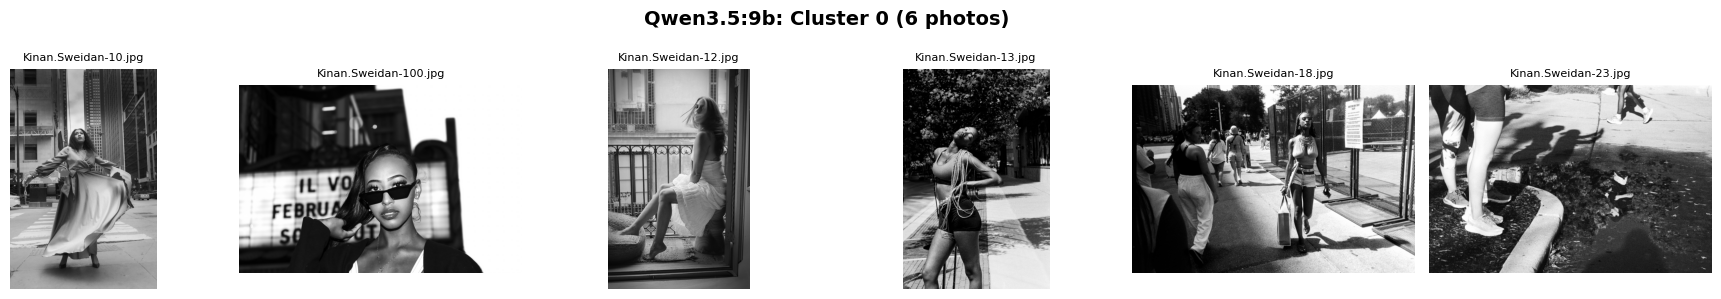

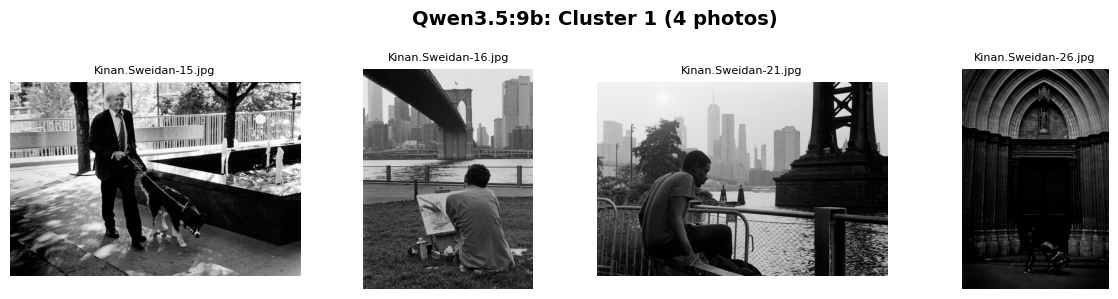

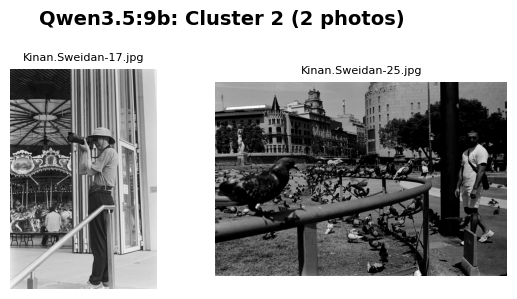

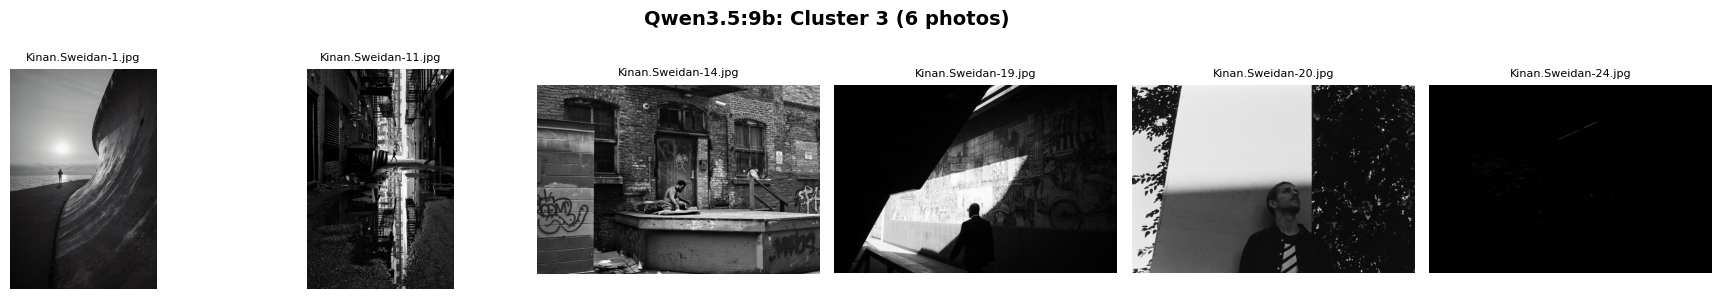

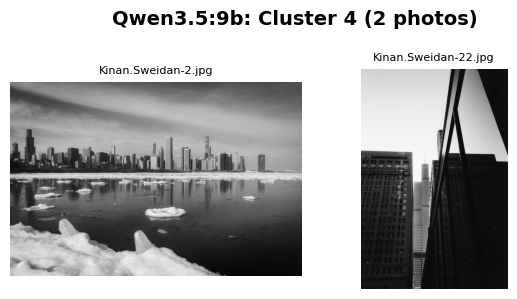


=== Qwen2.5-VL ===


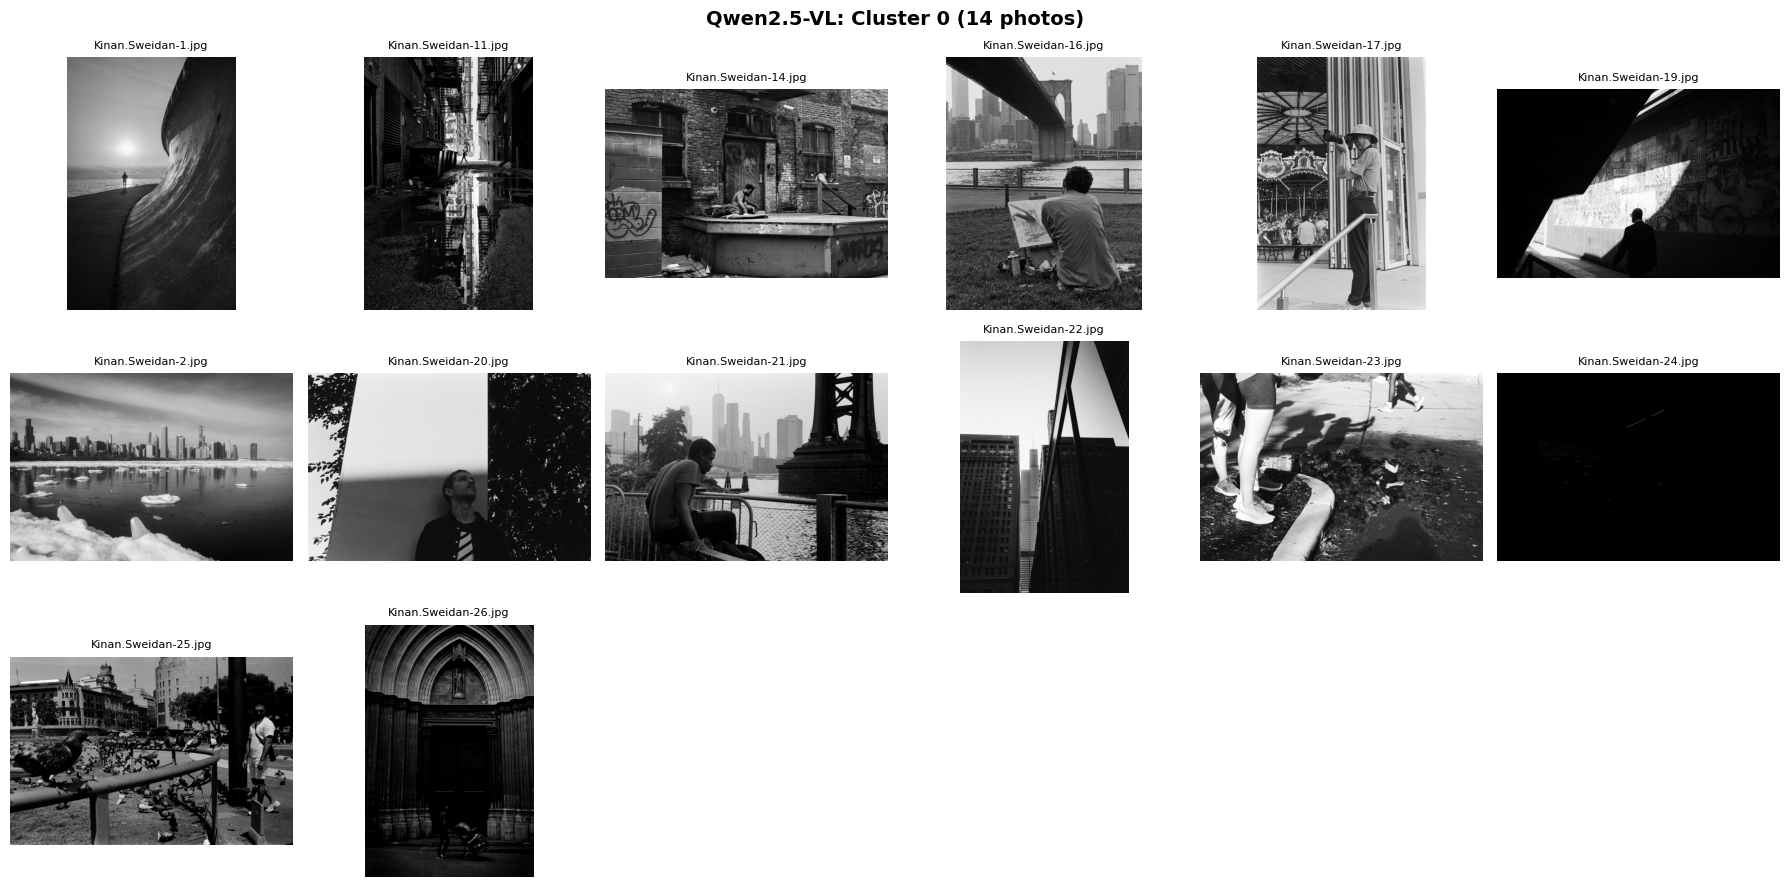

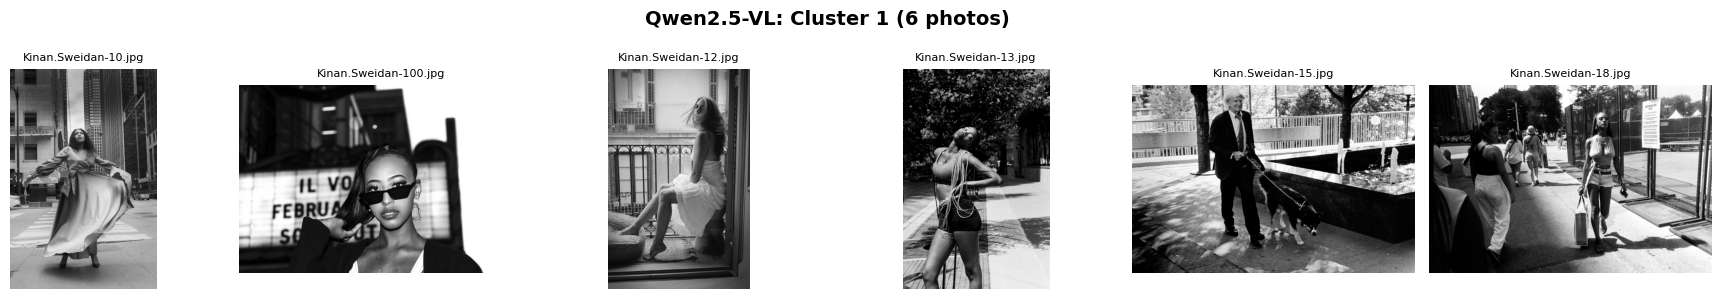

In [7]:
def show_clusters(data, label_key, title_prefix):
    clusters = {}
    for r in data:
        lbl = r[label_key]
        if lbl not in clusters: clusters[lbl] = []
        clusters[lbl].append(r)
    
    print(f"\n=== {title_prefix} ===")
    for lbl, group in sorted(clusters.items()):
        name = "Outliers" if lbl == -1 else f"Cluster {lbl}"
        n = len(group)
        cols = min(6, n)
        rows = (n // cols) + (1 if n % cols != 0 else 0)
        fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
        axes = axes.flatten() if n > 1 else [axes]
        for i, r in enumerate(group):
            axes[i].imshow(Image.open(r["path"]).convert("RGB"))
            axes[i].set_title(r["name"], fontsize=8)
            axes[i].axis("off")
        for j in range(i+1, len(axes)): axes[j].axis("off")
        plt.suptitle(f"{title_prefix}: {name} ({n} photos)", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

show_clusters(results, "q3_label", "Qwen3.5:9b")
show_clusters(results, "vlm_label", "Qwen2.5-VL")